In [7]:
from qdhmc import HMC
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

In [8]:
def guassian_log_prob(n, temp):
    def lp(x):
        return np.sum([-1 * x[i] for i in range(n)] + [-1 * x[i]**2 for i in range(n)])/temp
    return lp

def sphere_log_prob(n, temp):
    def lp(x):
        return -1 * np.sum([x[i]**2 for i in range(n)])/temp
    return lp

def double_well_log_prob(temp):
    def lp(x):
        return (-1*(x[0]**4 - 4 * x[0]**2 + x[1]**2) - 0.5 * x[0])/temp
    return lp

def rosenbrock(n, temp):
    def lp(x):
        return -1 * np.sum([10 * (x[i + 1] - x[i])**2 + (1 - x[i])**2 for i in range(n-1)])/temp
    return lp

def styblinski_tang(n, temp):
    def lp(x):
        return -1/2 * np.sum([x[i]**4 - 16 * x[i]**2 + 5 * x[i] for i in range(n)])/temp
    return lp

In [9]:
# from https://emcee.readthedocs.io/en/stable/tutorials/autocorr/

def next_pow_two(n):
    i = 1
    while i < n:
        i = i << 1
    return i

# Automated windowing procedure following Sokal (1989)
def auto_window(taus, c):
    m = np.arange(len(taus)) < c * taus
    if np.any(m):
        return np.argmin(m)
    return len(taus) - 1

def autocorr_func_1d(x, norm=True):
    x = np.atleast_1d(x)
    if len(x.shape) != 1:
        raise ValueError("invalid dimensions for 1D autocorrelation function")
    n = next_pow_two(len(x))

    # Compute the FFT and then (from that) the auto-correlation function
    f = np.fft.fft(x - np.mean(x), n=2 * n)
    acf = np.fft.ifft(f * np.conjugate(f))[: len(x)].real
    acf /= 4 * n

    # Optionally normalize
    if norm:
        acf /= (acf[0] + 1e-8)

    return acf

def autocorr_new(y, c=5.0):
    f = np.zeros(y.shape[1])
    for yy in y:
        f += autocorr_func_1d(yy)
    f /= len(y)
    taus = 2.0 * np.cumsum(f) - 1.0
    window = auto_window(taus, c)
    return taus[window]

In [10]:
def run_exp(t, rep, precision, n, log_prob, experiments, step_size):
    classical = []
    quantum = []

    test_c = HMC(log_prob, kernel_type='classical', num_vars=n, precision=precision, step_size=step_size)
    test_q = HMC(log_prob, kernel_type='quantum', precision=precision, r=rep, num_vars=n, t=t)
    
    for e in tqdm(range(experiments)):
        init_state = tf.random.uniform(shape=[n], minval=-tf.math.sqrt(2 * np.pi * 2 ** precision) / 2, \
                                        maxval=tf.math.sqrt(2 * np.pi * 2 ** precision) / 2)
        
        init = log_prob(init_state)

        s, m, std, a, rs = test_c.run_hmc(30_000, 0, init_state=init_state)
        s_q, m_q, std_q, a_q, rs_q = test_q.run_hmc(30_000, 0, init_state=init_state)

        classical.append(s)
        quantum.append(s_q)
        
    return classical, quantum

In [11]:
temps = [5.0]
experiments = 50

In [12]:
step_size = 0.07948701832532529
trotter_time = 1.6141954191198948
trotter_steps = 3
precision = 5
n = 2

In [13]:
c_dw = []
q_dw = []

for temp in temps:
    print(temp)
    log_prob = double_well_log_prob(temp)
    cc, qq = run_exp(trotter_time, trotter_steps, precision, n, log_prob, experiments, step_size)
    c_dw.append(cc)
    q_dw.append(qq)

np.save("c_dw.npy", np.array(c_dw))
np.save("q_dw.npy", np.array(q_dw))

5.0


  0%|          | 0/50 [00:00<?, ?it/s]

In [14]:
step_size = 0.314813295575933
trotter_time = 1.2669737917875925
trotter_steps = 6
precision = 6
n = 2

In [15]:
c_g = []
q_g = []

for temp in temps:
    print(temp)
    log_prob = guassian_log_prob(n, temp)
    cc, qq = run_exp(trotter_time, trotter_steps, precision, n, log_prob, experiments, step_size)
    c_g.append(cc)
    q_g.append(qq)
    
np.save("c_g.npy", np.array(c_g))
np.save("q_g.npy", np.array(q_g))

5.0


  0%|          | 0/50 [00:00<?, ?it/s]

In [16]:
step_size = 0.01905526527796041
trotter_time = 1.9015627356839464
trotter_steps = 3
precision = 2

In [17]:
c_r = []
q_r = []

for temp in temps:
    print(temp)
    log_prob = rosenbrock(n, temp)
    cc, qq = run_exp(trotter_time, trotter_steps, precision, n, log_prob, experiments, step_size)
    c_r.append(cc)
    q_r.append(qq)
    
np.save("c_r.npy", np.array(c_r))
np.save("q_r.npy", np.array(q_r))

5.0


  0%|          | 0/50 [00:00<?, ?it/s]

In [18]:
step_size = 0.016209118753477303
trotter_time = 1.1957011622141374
trotter_steps = 7
precision = 2
n = 2

In [19]:
c_st = []
q_st = []

for temp in temps:
    print(temp)
    log_prob = styblinski_tang(n, temp)
    cc, qq = run_exp(trotter_time, trotter_steps, precision, n, log_prob, experiments, step_size)
    c_st.append(cc)
    q_st.append(qq)

np.save("c_st.npy", np.array(c_st))
np.save("q_st.npy", np.array(q_st))

5.0


  0%|          | 0/50 [00:00<?, ?it/s]

In [20]:
exp = np.array(c_r[0])
exp.shape

(50, 30000, 2)

In [21]:
gaps = []

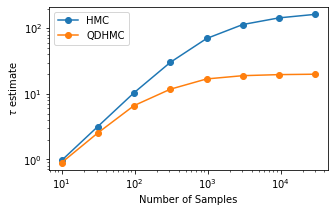

In [41]:
ac = []
aq = []

for i in range(len(c_dw[0][0][0])):
    chain = np.array(c_dw[0])[:, :, i]
    chain_q = np.array(q_dw[0])[:, :, i]

    N = np.exp(np.linspace(np.log(10), np.log(chain.shape[1]), 8)).astype(int)
    new = np.empty(len(N))
    new_q = np.empty(len(N))
    for i, n in enumerate(N):
        new[i] = autocorr_new(chain[:, :n])
        new_q[i] = autocorr_new(chain_q[:, :n])
    ac.append(new)
    aq.append(new_q)
        
gaps.append(new[-1] / new_q[-1])
#plt.title("Double Well")
plt.figure(figsize=(5, 3))
plt.loglog(N, np.mean(ac, axis=0), "o-", label="HMC")
plt.loglog(N, np.mean(aq, axis=0), "o-", label="QDHMC")
plt.xlabel("Number of Samples")
plt.ylabel(r"$\tau$ estimate")
plt.legend(fontsize=10)
plt.savefig("tau.png", dpi=300, bbox_inches="tight")
plt.show()

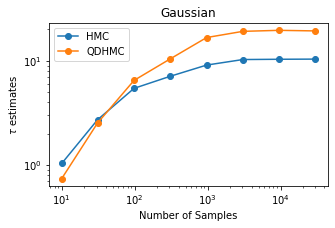

In [42]:
ac = []
aq = []

for i in range(len(c_g[0][0][0])):
    chain = np.array(c_g[0])[:, :, i]
    chain_q = np.array(q_g[0])[:, :, i]

    N = np.exp(np.linspace(np.log(10), np.log(chain.shape[1]), 8)).astype(int)
    new = np.empty(len(N))
    new_q = np.empty(len(N))
    for i, n in enumerate(N):
        new[i] = autocorr_new(chain[:, :n])
        new_q[i] = autocorr_new(chain_q[:, :n])
    ac.append(new)
    aq.append(new_q)
        
gaps.append(new[-1] / new_q[-1])
plt.figure(figsize=(5, 3))
plt.title("Gaussian")
plt.loglog(N, np.mean(ac, axis=0), "o-", label="HMC")
plt.loglog(N, np.mean(aq, axis=0), "o-", label="QDHMC")
plt.xlabel("Number of Samples")
plt.ylabel(r"$\tau$ estimates")
plt.legend(fontsize=10)
plt.savefig("tau_g.png", dpi=300, bbox_inches="tight")
plt.show()

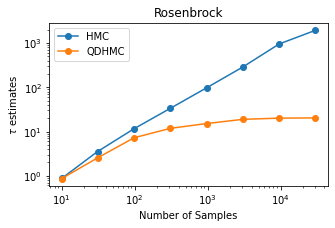

In [43]:
ac = []
aq = []

for i in range(len(c_r[0][0][0])):
    chain = np.array(c_r[0])[:, :, i]
    chain_q = np.array(q_r[0])[:, :, i]

    N = np.exp(np.linspace(np.log(10), np.log(chain.shape[1]), 8)).astype(int)
    new = np.empty(len(N))
    new_q = np.empty(len(N))
    for i, n in enumerate(N):
        new[i] = autocorr_new(chain[:, :n])
        new_q[i] = autocorr_new(chain_q[:, :n])
    ac.append(new)
    aq.append(new_q)
        
gaps.append(new[-1] / new_q[-1])
plt.figure(figsize=(5, 3))
plt.title("Rosenbrock")
plt.loglog(N, np.mean(ac, axis=0), "o-", label="HMC")
plt.loglog(N, np.mean(aq, axis=0), "o-", label="QDHMC")
plt.xlabel("Number of Samples")
plt.ylabel(r"$\tau$ estimates")
plt.legend(fontsize=10)
plt.savefig("tau_r.png", dpi=300, bbox_inches="tight")
plt.show()

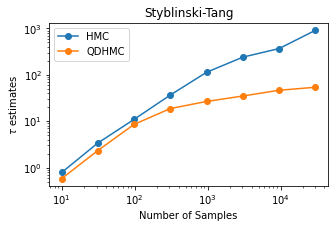

In [44]:
ac = []
aq = []

for i in range(len(c_st[0][0][0])):
    chain = np.array(c_st[0])[:, :, i]
    chain_q = np.array(q_st[0])[:, :, i]

    N = np.exp(np.linspace(np.log(10), np.log(chain.shape[1]), 8)).astype(int)
    new = np.empty(len(N))
    new_q = np.empty(len(N))
    for i, n in enumerate(N):
        new[i] = autocorr_new(chain[:, :n])
        new_q[i] = autocorr_new(chain_q[:, :n])
    ac.append(new)
    aq.append(new_q)
        
gaps.append(new[-1] / new_q[-1])
plt.figure(figsize=(5, 3))
plt.title("Styblinski-Tang")
plt.loglog(N, np.mean(ac, axis=0), "o-", label="HMC")
plt.loglog(N, np.mean(aq, axis=0), "o-", label="QDHMC")
plt.xlabel("Number of Samples")
plt.ylabel(r"$\tau$ estimates")
plt.legend(fontsize=10)
plt.savefig("tau_st.png", dpi=300, bbox_inches="tight")
plt.show()

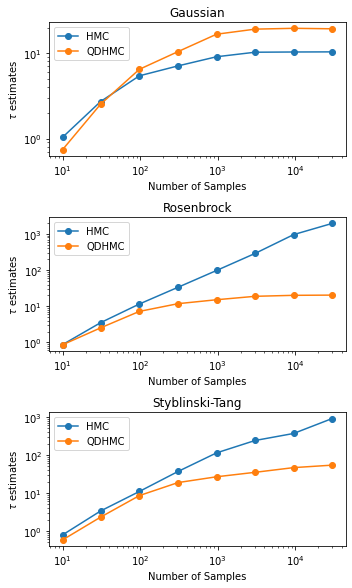

In [46]:
import numpy as np
import matplotlib.pyplot as plt

ac = []
aq = []

# Process Gaussian
for i in range(len(c_g[0][0][0])):
    chain = np.array(c_g[0])[:, :, i]
    chain_q = np.array(q_g[0])[:, :, i]

    N = np.exp(np.linspace(np.log(10), np.log(chain.shape[1]), 8)).astype(int)
    new = np.empty(len(N))
    new_q = np.empty(len(N))
    for j, n in enumerate(N):
        new[j] = autocorr_new(chain[:, :n])
        new_q[j] = autocorr_new(chain_q[:, :n])
    ac.append(new)
    aq.append(new_q)

gaps.append(new[-1] / new_q[-1])

# Process Rosenbrock
ac_r = []
aq_r = []
for i in range(len(c_r[0][0][0])):
    chain = np.array(c_r[0])[:, :, i]
    chain_q = np.array(q_r[0])[:, :, i]

    N = np.exp(np.linspace(np.log(10), np.log(chain.shape[1]), 8)).astype(int)
    new = np.empty(len(N))
    new_q = np.empty(len(N))
    for j, n in enumerate(N):
        new[j] = autocorr_new(chain[:, :n])
        new_q[j] = autocorr_new(chain_q[:, :n])
    ac_r.append(new)
    aq_r.append(new_q)

gaps.append(new[-1] / new_q[-1])

# Process Styblinski-Tang
ac_st = []
aq_st = []
for i in range(len(c_st[0][0][0])):
    chain = np.array(c_st[0])[:, :, i]
    chain_q = np.array(q_st[0])[:, :, i]

    N = np.exp(np.linspace(np.log(10), np.log(chain.shape[1]), 8)).astype(int)
    new = np.empty(len(N))
    new_q = np.empty(len(N))
    for j, n in enumerate(N):
        new[j] = autocorr_new(chain[:, :n])
        new_q[j] = autocorr_new(chain_q[:, :n])
    ac_st.append(new)
    aq_st.append(new_q)

gaps.append(new[-1] / new_q[-1])

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(5, 9))
# Gaussian subplot
axes[0].loglog(N, np.mean(ac, axis=0), "o-", label="HMC")
axes[0].loglog(N, np.mean(aq, axis=0), "o-", label="QDHMC")
axes[0].set_title("Gaussian")
axes[0].set_xlabel("Number of Samples")
axes[0].set_ylabel(r"$\tau$ estimates")
axes[0].legend(fontsize=10)

# Rosenbrock subplot
axes[1].loglog(N, np.mean(ac_r, axis=0), "o-", label="HMC")
axes[1].loglog(N, np.mean(aq_r, axis=0), "o-", label="QDHMC")
axes[1].set_title("Rosenbrock")
axes[1].set_xlabel("Number of Samples")
axes[1].set_ylabel(r"$\tau$ estimates")
axes[1].legend(fontsize=10)

# Styblinski-Tang subplot
axes[2].loglog(N, np.mean(ac_st, axis=0), "o-", label="HMC")
axes[2].loglog(N, np.mean(aq_st, axis=0), "o-", label="QDHMC")
axes[2].set_title("Styblinski-Tang")
axes[2].set_xlabel("Number of Samples")
axes[2].set_ylabel(r"$\tau$ estimates")
axes[2].legend(fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("tau_combined.png", dpi=300, bbox_inches="tight")
plt.show()


In [29]:
n = 1 / np.array(gaps)
print(n)
print(n.mean())
print(n.std())

[0.0991496  1.82132679 0.0103864  0.08318229 0.08318229]
0.4194454754380656
0.7016175389862513
